In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

%matplotlib inline


apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")
apps.shape, reviews.shape



((10841, 13), (64295, 5))

In [37]:
apps.head()
reviews.head()


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [38]:
apps.info()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
--

In [39]:
apps_hf = apps[apps["Category"].isin(["HEALTH_AND_FITNESS", "Health & Fitness"])]
df.shape

(480, 7)

In [15]:
top_apps = apps_hf.sort_values("Reviews", ascending=False).head(30)

In [40]:
df = reviews.merge(
    top_apps[["App", "Rating", "Reviews"]],
    on="App",
    how="inner"
)
df.shape

(480, 7)

In [41]:
df = df.dropna(subset=["Translated_Review"])
df = df[df["Translated_Review"].str.len() >= 10]
df = df.drop_duplicates(subset=["App", "Translated_Review"])
df.shape

(103, 7)

In [42]:
df["Review_Length"] = df["Translated_Review"].apply(len)
df["Review_Length"].describe()


count    103.000000
mean      49.174757
std       54.970300
min       10.000000
25%       17.500000
50%       26.000000
75%       51.500000
max      354.000000
Name: Review_Length, dtype: float64

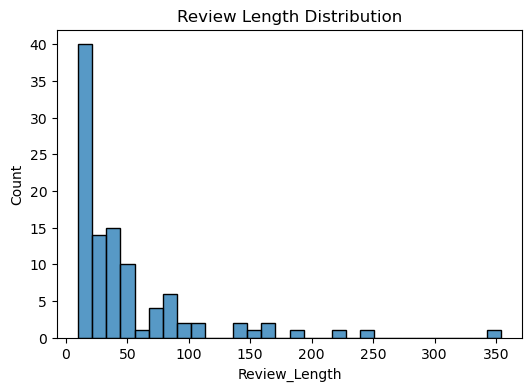

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df["Review_Length"], bins=30)
plt.title("Review Length Distribution")
plt.show()


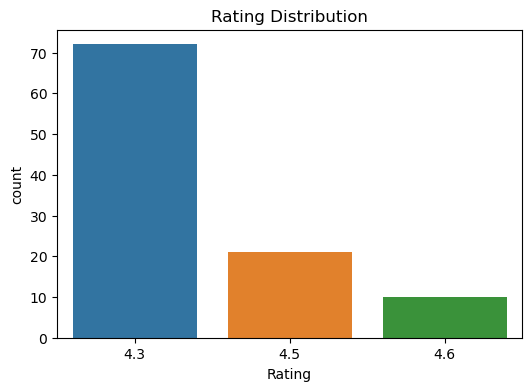

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x="Rating", data=df)
plt.title("Rating Distribution")
plt.show()


In [46]:
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

df["vader_scores"] = df["Translated_Review"].apply(
    lambda x: sia.polarity_scores(x)
)

df["compound"] = df["vader_scores"].apply(lambda x: x["compound"])
def vader_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["VADER_Sentiment"] = df["compound"].apply(vader_label)
pd.crosstab(df["Rating"], df["VADER_Sentiment"], normalize="index") * 100


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


VADER_Sentiment,Negative,Neutral,Positive
Rating,,,
4.3,8.333333,16.666667,75.000000
4.5,14.285714,9.523810,76.190476
4.6,20.000000,20.000000,60.000000


In [49]:
import os

os.makedirs("data/processed", exist_ok=True)


In [53]:
df.to_csv("data/processed/M1_clean_reviews.csv", index=False)
